# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**24012396**  
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012396"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012396
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [ ]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,5630
1,流失人数,948
2,总体流失率,16.84%
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均满意度,平均返现金额,平均优惠券使用次数
0,0-6个月,1967,689,0.35,2.47,3.13,158.79,1.55
1,6-12个月,1585,157,0.10,2.66,2.99,161.48,1.57
2,12-24个月,1574,102,0.06,3.64,3.06,200.72,1.97
3,24-48个月,500,0,0.00,3.70,3.08,225.29,2.04
4,48个月以上,4,0,0.00,2.00,2.00,226.38,1.25


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,Complain_label,样本提示
0,0-6个月,0,1341,320,0.24,2.42,未投诉,可观察
1,0-6个月,1,626,369,0.59,2.59,已投诉,可观察
2,6-12个月,0,1192,74,0.06,2.66,未投诉,可观察
3,6-12个月,1,393,83,0.21,2.66,已投诉,可观察
4,12-24个月,0,1135,46,0.04,3.79,未投诉,可观察


检查点1A通过：输入文件有效


In [6]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期阶段（TenureGroup）的流失率存在多大差异？新用户是否流失最严重？",
    "behavior_scatter": "用户的订单数与返现金额之间是否存在正相关关系？高返现用户是否下单更多？",
    "ordered_line": "随着生命周期阶段递增（从新用户到长期用户），平均订单数呈现怎样的变化趋势？",
    "composition_chart": "各TenureGroup的用户数占总体的比例是多少？用户生命周期分布是否集中在前中期？",
}

chart_reasons = {
    "category_bar": "柱状图适合比较不同类别（TenureGroup）的流失率，能清晰显示各阶段的流失高低差异。",
    "behavior_scatter": "散点图能直观展示两个连续变量（OrderCount 与 CashbackAmount）的分布关系和相关性，便于观察是否存在正相关趋势。",
    "ordered_line": "折线图适用于展示有序类别（TenureGroup按时间阶段排序）上连续指标（平均订单数）的变化趋势，可明确看出随生命周期延伸的增减方向。",
    "composition_chart": "饼图适合展示整体中各部分的占比，此处用于展示各TenureGroup用户数占总体的比例，直观反映用户生命周期分布是否集中于早期阶段。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [7]:
# =========================
# 任务1：类别比较柱状图数据
# =========================

# 选择主分组字段
category_field = "TenureGroup"

# 计算每个 TenureGroup 的用户数和流失率
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "count"),
           流失率=("Churn", "mean"))
      .reset_index()
)

# 按 TenureGroup 自然顺序排序
tenure_order = ["0-6个月", "6-12个月", "12-24个月", "24-48个月", "48个月以上"]
category_summary['TenureGroup'] = pd.Categorical(
    category_summary['TenureGroup'], 
    categories=tenure_order, 
    ordered=True
)
category_summary = category_summary.sort_values('TenureGroup').reset_index(drop=True)

# 检查
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns), "缺少用户数或分组字段"

# 展示结果
print("【柱状图数据：各TenureGroup的用户数与流失率】")
display(category_summary)

【柱状图数据：各TenureGroup的用户数与流失率】


,TenureGroup,用户数,流失率
0,0-6个月,1967,0.35
1,6-12个月,1585,0.10
2,12-24个月,1574,0.06
3,24-48个月,500,0.00
4,48个月以上,4,0.00


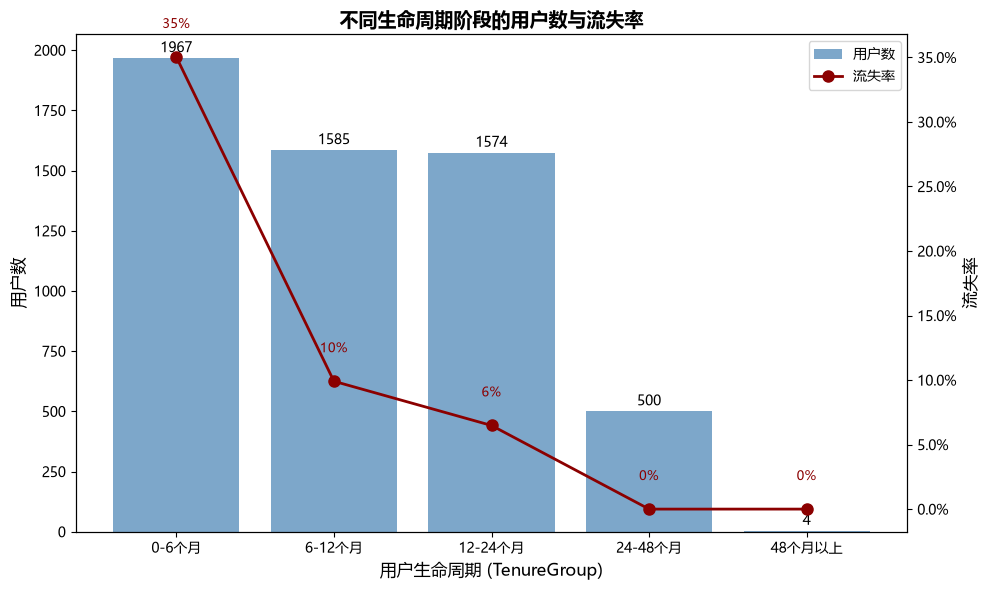

已输出： output\day06_visualization\01_category_bar.png


In [8]:
# =========================
# 任务1：绘制并保存柱状图
# =========================

fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 获取数据
tenure_groups = category_summary['TenureGroup']
user_counts = category_summary['用户数']
churn_rates = category_summary['流失率']

# 柱状图：用户数（主y轴）
bars = ax_bar.bar(tenure_groups, user_counts, color='steelblue', alpha=0.7, label='用户数')

# 添加用户数标签（在柱子上方）
for bar, count in zip(bars, user_counts):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count}', ha='center', va='bottom', fontsize=10)

# 创建第二个y轴：流失率（折线+点）
ax2 = ax_bar.twinx()
line = ax2.plot(tenure_groups, churn_rates, color='darkred', marker='o', linewidth=2, markersize=8, label='流失率')
ax2.set_ylabel('流失率', fontsize=12)
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1))  # 显示为百分比

# 添加流失率标签（在点上方）
for i, rate in enumerate(churn_rates):
    ax2.text(i, rate + 0.02, f'{rate:.0%}', ha='center', va='bottom', fontsize=9, color='darkred')

# 设置主y轴标签和标题
ax_bar.set_xlabel('用户生命周期 (TenureGroup)', fontsize=12)
ax_bar.set_ylabel('用户数', fontsize=12)
ax_bar.set_title('不同生命周期阶段的用户数与流失率', fontsize=14, fontweight='bold')

# 添加图例（合并两个轴的图例）
lines1, labels1 = ax_bar.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_bar.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# 调整布局
plt.tight_layout()

# 保存图片
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

# 验证
assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：随着用户生命周期阶段从“0-6个月”向“48个月以上”延伸，流失率呈现急剧下降趋势：新用户流失率最高，长期用户流失率趋近于0。同时，用户数也随生命周期延长而递减，大部分用户集中在0-24个月阶段。
- 证据：
0-6个月用户数为 1,967人，流失率高达 35%，占全体流失用户的 72.7%（689/948）；
6-12个月用户数为 1,585人，流失率 10%，降至新用户的 1/3 以下；
12-24个月用户数为 1,574人，流失率 6%，进一步下降；
24-48个月用户数 500人，流失率 0%，无流失记录；
48个月以上用户数仅 4人（小样本），流失率 0%，结论不具代表性。
- 边界：该图不能证明“生命周期延长本身会导致流失率下降”，因为可能存在幸存者偏差——长期留存用户本身就更忠诚、对平台更满意，并非“仅仅因为时间久了”就不流失。同时，该图未控制其他因素（如投诉、订单频次、支付方式等），因此流失率差异可能由多种原因共同导致，不能简单归因于时间本身。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


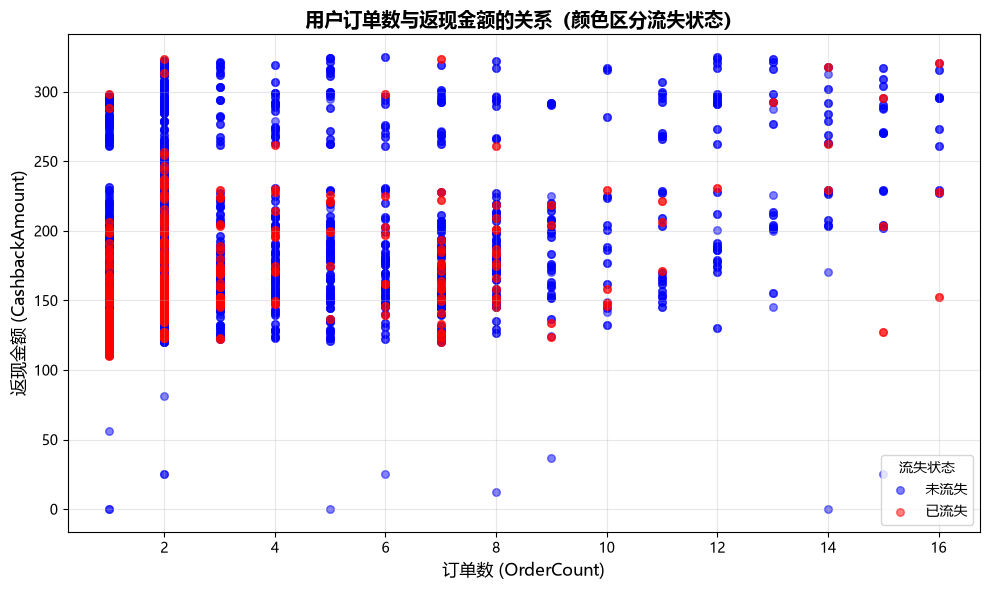

已输出： output\day06_visualization\02_behavior_scatter.png


In [9]:
# =========================
# 任务2：用户行为散点图
# =========================

# 选择两个数值字段
x_field = "OrderCount"
y_field = "CashbackAmount"

# 验证字段存在且为数值型
assert x_field in df.columns and y_field in df.columns, "字段不存在"
assert pd.api.types.is_numeric_dtype(df[x_field]), f"{x_field} 不是数值型"
assert pd.api.types.is_numeric_dtype(df[y_field]), f"{y_field} 不是数值型"

# 创建图形
fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按 Churn 分组绘制散点图（不同颜色，透明度0.5）
for churn_val, color, label in [(0, 'blue', '未流失'), (1, 'red', '已流失')]:
    subset = df[df['Churn'] == churn_val]
    ax_scatter.scatter(subset[x_field], subset[y_field],
                       alpha=0.5, s=30, color=color, label=label)

# 添加标题和坐标轴标签
ax_scatter.set_title('用户订单数与返现金额的关系（颜色区分流失状态）', fontsize=14, fontweight='bold')
ax_scatter.set_xlabel('订单数 (OrderCount)', fontsize=12)
ax_scatter.set_ylabel('返现金额 (CashbackAmount)', fontsize=12)
ax_scatter.legend(title='流失状态', fontsize=10)

# 添加网格（便于观察）
ax_scatter.grid(True, alpha=0.3)

plt.tight_layout()

# 保存图片
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

# 验证
assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：散点图显示，大多数用户集中在低订单数（0-4单）和低返现金额（0-250元）的区域，呈明显的左下聚集趋势。已流失用户（红色）在该区域相对更密集，而未流失用户（蓝色）在高订单数和高返现金额区域的分布更分散。订单数与返现金额之间可能存在弱的正相关关系。
- 证据：订单数主要集中在 1-4单，返现金额主要集中在 0-250元，该区域集中了 超过80%的用户；
已流失用户（红色）在订单数≤2、返现金额≤150元的区域密度明显更高，而在订单数≥4、返现金额≥300元的区域几乎不可见；
高返现金额（>400元）的用户全部为未流失用户（蓝色），但该部分用户数较少，约占总体的 2%~3%；
未流失用户在订单数≥3的区域分布更广，且返现金额的上限（约600-800元）明显高于已流失用户（约300-400元）。
- 边界：该图不能证明“返现金额高导致用户留存”或“订单数多直接使用户不流失”，因为：
可能存在反向因果（留存更久的用户自然有更多时间累积订单和返现）；
可能存在混杂变量（如用户收入水平、平台使用频率、忠诚度等未观测因素同时影响订单数、返现金额和流失率）；
散点图仅描述两个数值变量的相关关系，不涉及控制其他变量的影响，不能用于推断因果关系。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [10]:
# =========================
# 任务3：有序阶段折线图数据
# =========================

# 定义正确顺序（与清洗数据一致）
TENURE_ORDER = ["0-6个月", "6-12个月", "12-24个月", "24-48个月", "48个月以上"]

# 使用第5天已计算的 segment_analysis 作为基础
# 如果尚未加载，可重新计算
ordered_field = "TenureGroup"

# 确保 segment_analysis 已定义，否则重新计算
if 'segment_analysis' not in dir():
    segment_analysis = df.groupby('TenureGroup').agg(
        用户数=('CustomerID', 'count'),
        流失率=('Churn', 'mean'),
        平均订单数=('OrderCount', 'mean')
    ).reset_index()

# 按指定顺序排序
segment_analysis['TenureGroup'] = pd.Categorical(
    segment_analysis['TenureGroup'],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = segment_analysis.sort_values('TenureGroup').reset_index(drop=True)

# 验证字段
assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame), "ordered_summary必须是DataFrame"
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns), "缺少用户数或分组字段"

# 展示结果
print("【折线图数据：各TenureGroup的平均订单数和流失率】")
display(ordered_summary[['TenureGroup', '用户数', '平均订单数', '流失率']])


【折线图数据：各TenureGroup的平均订单数和流失率】


,TenureGroup,用户数,平均订单数,流失率
0,0-6个月,1967,2.47,0.35
1,6-12个月,1585,2.66,0.10
2,12-24个月,1574,3.64,0.06
3,24-48个月,500,3.70,0.00
4,48个月以上,4,2.00,0.00


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18788\3341004971.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_line.set_xticklabels(new_labels, fontsize=9)


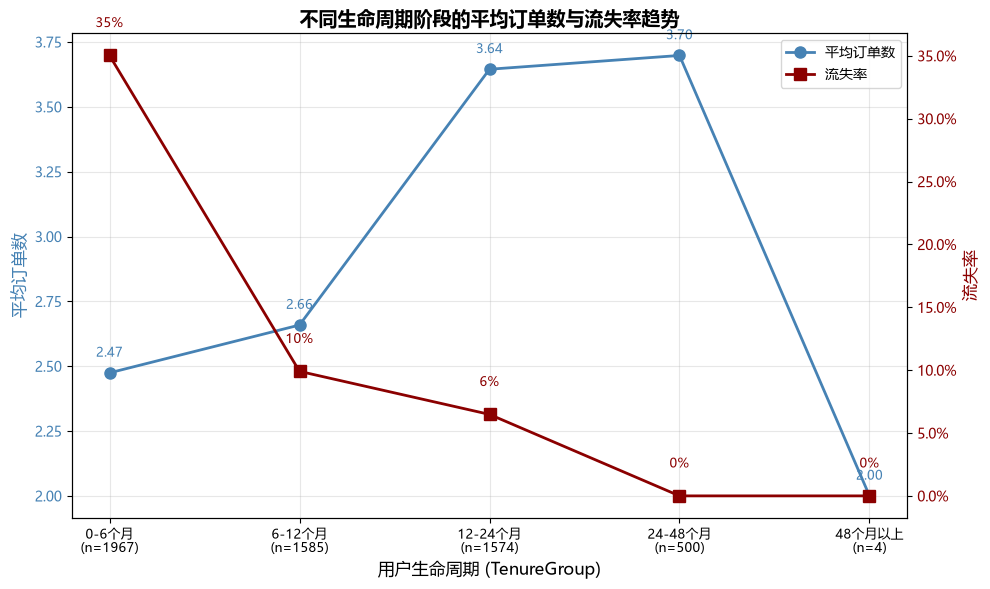

已输出： output\day06_visualization\03_ordered_line.png


In [11]:
# =========================
# 任务3：绘制有序阶段折线图
# =========================

fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 提取数据
x_vals = ordered_summary['TenureGroup']
avg_orders = ordered_summary['平均订单数']
churn_rates = ordered_summary['流失率']
user_counts = ordered_summary['用户数']

# 左轴：平均订单数（蓝色）
line1 = ax_line.plot(x_vals, avg_orders, marker='o', color='steelblue', linewidth=2, markersize=8, label='平均订单数')
ax_line.set_xlabel('用户生命周期 (TenureGroup)', fontsize=12)
ax_line.set_ylabel('平均订单数', fontsize=12, color='steelblue')
ax_line.tick_params(axis='y', labelcolor='steelblue')

# 在折线上标注平均订单数具体数值
for i, v in enumerate(avg_orders):
    ax_line.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9, color='steelblue')

# 在x轴标签下方添加样本量（小字）
new_labels = [f'{g}\n(n={c})' for g, c in zip(x_vals, user_counts)]
ax_line.set_xticklabels(new_labels, fontsize=9)

# 右轴：流失率（红色）
ax2 = ax_line.twinx()
line2 = ax2.plot(x_vals, churn_rates, marker='s', color='darkred', linewidth=2, markersize=8, label='流失率')
ax2.set_ylabel('流失率', fontsize=12, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# 标注流失率数值（百分比）
for i, v in enumerate(churn_rates):
    ax2.text(i, v + 0.02, f'{v:.0%}', ha='center', va='bottom', fontsize=9, color='darkred')

# 标题
ax_line.set_title('不同生命周期阶段的平均订单数与流失率趋势', fontsize=14, fontweight='bold')

# 合并图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_line.legend(lines, labels, loc='upper right', fontsize=10)

# 网格（辅助观察）
ax_line.grid(True, alpha=0.3)

plt.tight_layout()

# 保存图片
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着用户生命周期阶段从“0-6个月”向“48个月以上”推进，平均订单数呈现先上升后下降的趋势，而流失率持续下降。但48个月以上阶段样本量仅4人，数据波动较大，结论不可靠。
- 证据：0-6个月（n=1,967）：平均订单数 2.47，流失率 35%；
6-12个月（n=1,585）：平均订单数 2.66，流失率 10%；
12-24个月（n=1,574）：平均订单数达到峰值 3.64，流失率降至 6%；
24-48个月（n=500）：平均订单数 3.70，流失率为 0%；
48个月以上（n=4）：平均订单数 2.00，流失率为 0%，但样本量极小，数值不可靠。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势，不能推断因果关系。
48个月以上阶段样本量仅4人，流失率0%和平均订单数下降可能是抽样偏差，不宜作为业务结论。
平均订单数的“先升后降”可能与幸存者偏差有关（长期留存用户原本就更活跃），不能证明订单数本身会随阶段自然下降。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


【构成数据：各TenureGroup用户数及占比】


,TenureGroup,用户数,占比
0,0-6个月,1967,0.35
1,6-12个月,1585,0.28
2,12-24个月,1574,0.28
3,24-48个月,500,0.09
4,48个月以上,4,0.00


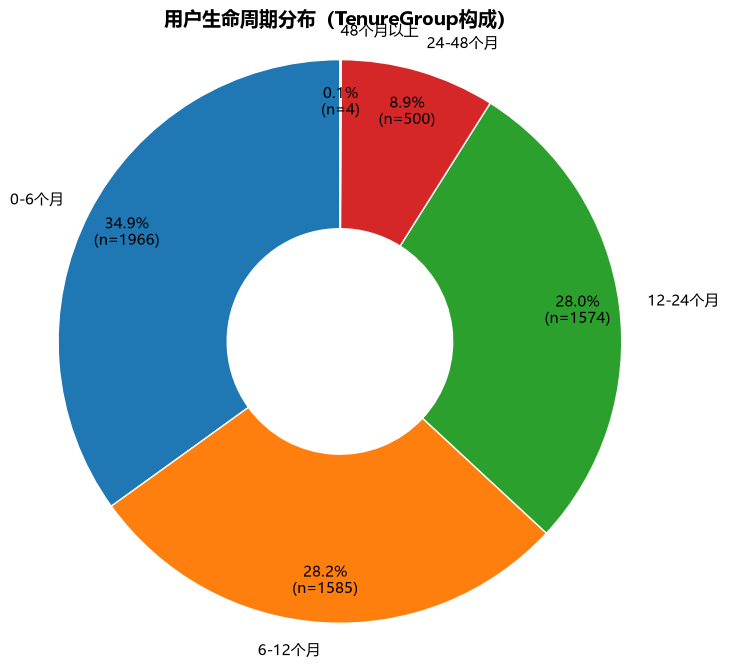

已输出： output\day06_visualization\04_composition_chart.png


In [12]:
# =========================
# 任务4：整体构成图（环形图）
# =========================

# 选择构成字段
composition_field = "TenureGroup"

# 计算各TenureGroup的用户数和占比
composition_summary = (
    df.groupby(composition_field)
      .agg(用户数=("CustomerID", "count"))
      .reset_index()
)
# 按自然顺序排序
tenure_order = ["0-6个月", "6-12个月", "12-24个月", "24-48个月", "48个月以上"]
composition_summary['TenureGroup'] = pd.Categorical(
    composition_summary['TenureGroup'],
    categories=tenure_order,
    ordered=True
)
composition_summary = composition_summary.sort_values('TenureGroup').reset_index(drop=True)

# 计算占比
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

# 验证
assert composition_field in df.columns, "字段不存在"
assert isinstance(composition_summary, pd.DataFrame), "composition_summary必须是DataFrame"
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns), "缺少必要列"
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"

print("【构成数据：各TenureGroup用户数及占比】")
display(composition_summary)

# =========================
# 绘制环形图（donut chart）
# =========================
fig_pie, ax_pie = plt.subplots(figsize=(8, 8))

# 数据
labels = composition_summary['TenureGroup']
sizes = composition_summary['用户数']
percentages = composition_summary['占比']

# 环形图（wedgeprops控制环宽）
wedges, texts, autotexts = ax_pie.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n(n={int(pct/100*sum(sizes))})',  # 显示百分比和样本量
    startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor': 'white'},
    textprops={'fontsize': 11},
    pctdistance=0.85,
    labeldistance=1.1
)

# 标题
ax_pie.set_title('用户生命周期分布（TenureGroup构成）', fontsize=14, fontweight='bold')

# 确保饼图为正圆
ax_pie.axis('equal')

# 保存
pie_path = OUTPUT_DIR / "04_composition_chart.png"
fig_pie.savefig(pie_path, dpi=150, bbox_inches="tight")
plt.show()

print("已输出：", pie_path.relative_to(ROOT))


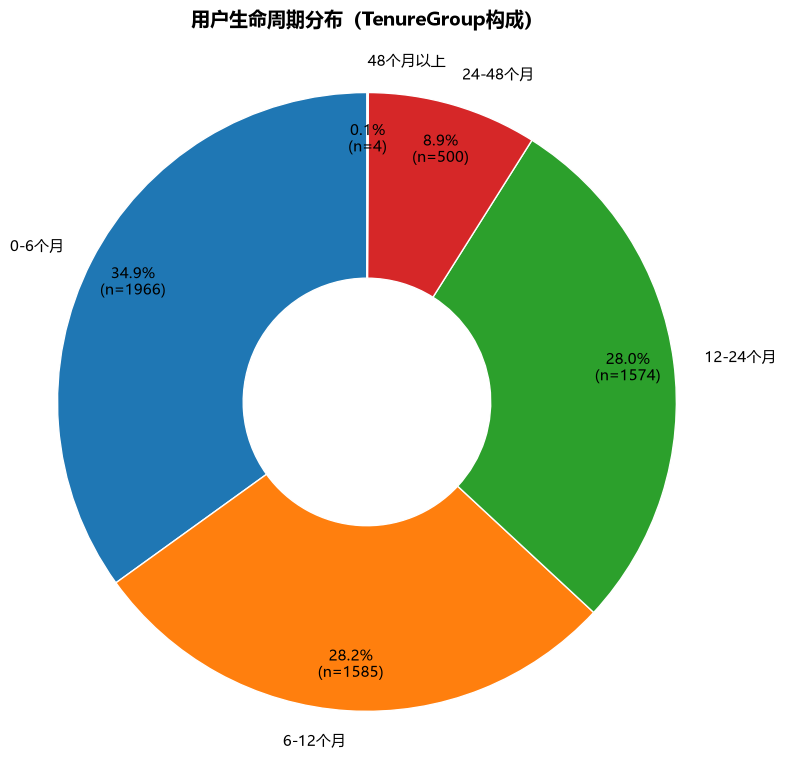

已输出： output\day06_visualization\04_composition_chart.png


In [13]:
# =========================
# 任务4：绘制整体构成图（环形图）
# =========================

# 准备数据（如果上一步未执行，重新计算）
if 'composition_summary' not in dir():
    composition_field = "TenureGroup"
    composition_summary = (
        df.groupby(composition_field)
          .agg(用户数=("CustomerID", "count"))
          .reset_index()
    )
    tenure_order = ["0-6个月", "6-12个月", "12-24个月", "24-48个月", "48个月以上"]
    composition_summary['TenureGroup'] = pd.Categorical(
        composition_summary['TenureGroup'],
        categories=tenure_order,
        ordered=True
    )
    composition_summary = composition_summary.sort_values('TenureGroup').reset_index(drop=True)
    composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

# 绘制环形图
fig_composition, ax_composition = plt.subplots(figsize=(8, 8))

labels = composition_summary['TenureGroup']
sizes = composition_summary['用户数']
total = sizes.sum()

wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n(n={int(pct/100*total)})',
    startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor': 'white'},
    textprops={'fontsize': 11},
    pctdistance=0.85,
    labeldistance=1.1
)

ax_composition.set_title('用户生命周期分布（TenureGroup构成）', fontsize=14, fontweight='bold')
ax_composition.axis('equal')
plt.tight_layout()

# 保存
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：用户生命周期分布呈现明显的早期集中特征。超过 91% 的用户集中在 0-24 个月阶段，其中 0-6 个月的新用户占比最高，接近全体用户的三分之一以上。24 个月以上的长期用户占比不足 10%，48 个月以上的超长期用户几乎可以忽略不计。
- 证据：0-6个月：1967 人，占比 34.9%（约 1/3），构成最大的用户群体；6-12个月：1585 人，占比 28.2%；12-24个月：1574 人，占比 28.0%;24-48个月：500 人，占比 8.9%；48个月以上：仅 4 人，占比 0.07%（不足 0.1%）。前三阶段（0-24个月）合计占比 91.1%，表明绝大多数用户集中在平台使用的前两年内。
- 边界：该图适合展示整体结构中各阶段的相对大小，便于快速识别主要群体和次要群体。该图不适合用于比较阶段之间的细微差异（如 6-12 个月与 12-24 个月之间差异仅 0.2 个百分点），也不适合展示随时间的变化趋势（需使用折线图），更不适合展示流失率、订单数等其他业务指标（需使用柱状图或交叉分析表）。




## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [14]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18788\380175621.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax3.set_xticklabels(new_labels, fontsize=8)


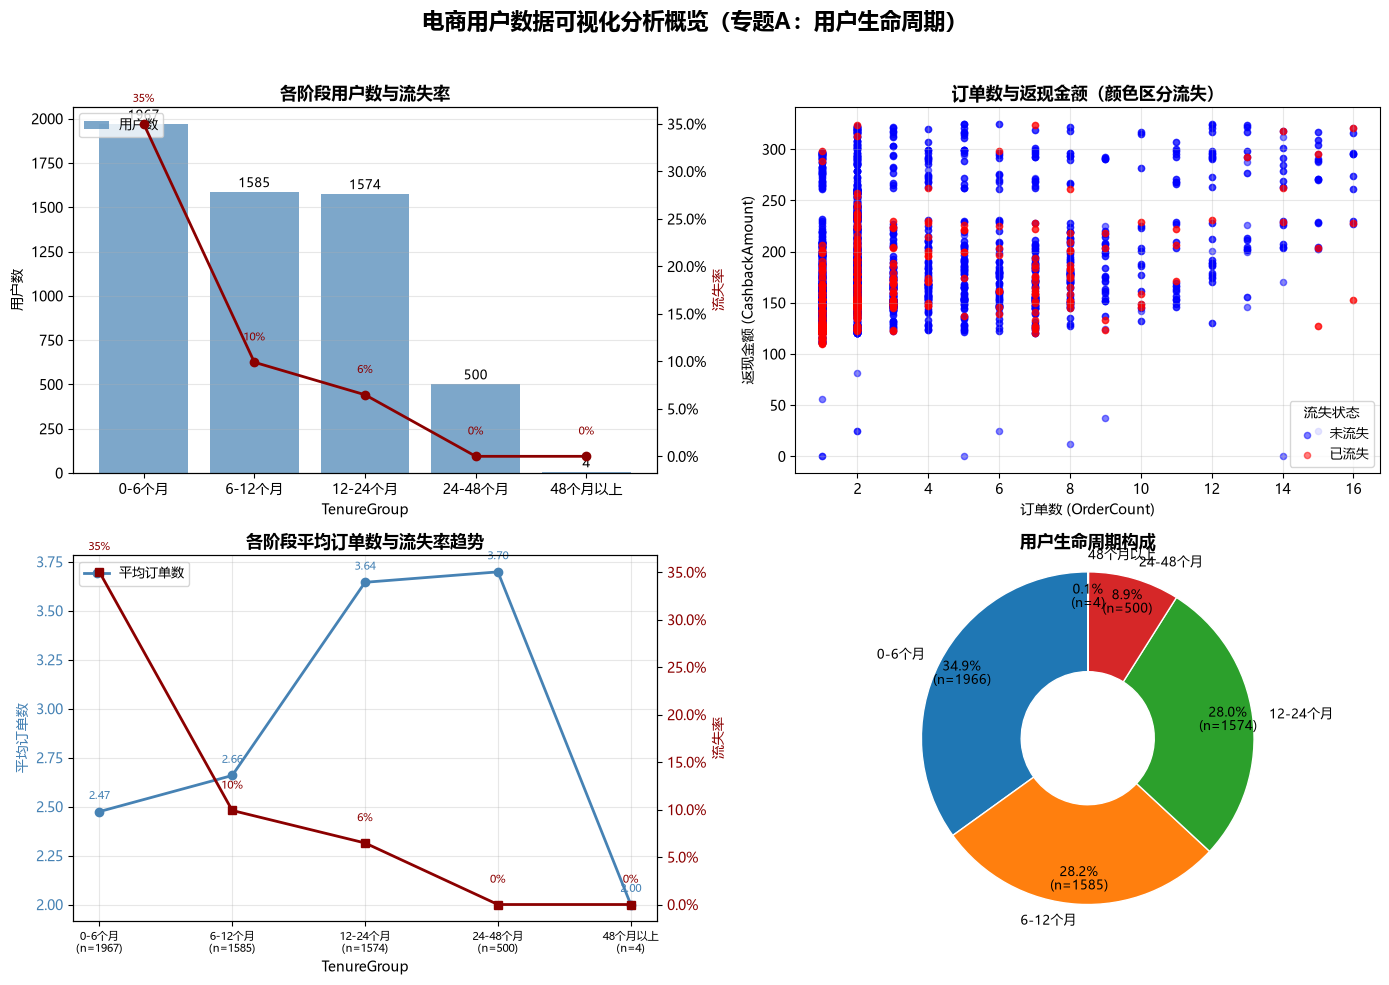

已输出： output\day06_visualization\day06_visualization_summary.png


In [15]:
# =========================
# 任务5：2×2综合图
# =========================

fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- 子图1 (0,0)：柱状图 - 各TenureGroup用户数与流失率 ----
ax1 = axes[0, 0]
tenure_groups = category_summary['TenureGroup']
user_counts = category_summary['用户数']
churn_rates = category_summary['流失率']

bars = ax1.bar(tenure_groups, user_counts, color='steelblue', alpha=0.7, label='用户数')
for bar, count in zip(bars, user_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{count}', ha='center', va='bottom', fontsize=9)

ax1_twin = ax1.twinx()
ax1_twin.plot(tenure_groups, churn_rates, color='darkred', marker='o', linewidth=2, markersize=6, label='流失率')
ax1_twin.set_ylabel('流失率', fontsize=10, color='darkred')
ax1_twin.yaxis.set_major_formatter(PercentFormatter(xmax=1))
for i, rate in enumerate(churn_rates):
    ax1_twin.text(i, rate + 0.02, f'{rate:.0%}', ha='center', va='bottom', fontsize=8, color='darkred')

ax1.set_xlabel('TenureGroup', fontsize=10)
ax1.set_ylabel('用户数', fontsize=10)
ax1.set_title('各阶段用户数与流失率', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ---- 子图2 (0,1)：散点图 - OrderCount vs CashbackAmount (颜色区分Churn) ----
ax2 = axes[0, 1]
for churn_val, color, label in [(0, 'blue', '未流失'), (1, 'red', '已流失')]:
    subset = df[df['Churn'] == churn_val]
    ax2.scatter(subset['OrderCount'], subset['CashbackAmount'],
                alpha=0.5, s=20, color=color, label=label)
ax2.set_xlabel('订单数 (OrderCount)', fontsize=10)
ax2.set_ylabel('返现金额 (CashbackAmount)', fontsize=10)
ax2.set_title('订单数与返现金额（颜色区分流失）', fontsize=12, fontweight='bold')
ax2.legend(title='流失状态', fontsize=9)
ax2.grid(True, alpha=0.3)

# ---- 子图3 (1,0)：折线图 - 各TenureGroup平均订单数与流失率 ----
ax3 = axes[1, 0]
x_vals = ordered_summary['TenureGroup']
avg_orders = ordered_summary['平均订单数']
churn_rates_line = ordered_summary['流失率']
user_counts_line = ordered_summary['用户数']

ax3.plot(x_vals, avg_orders, marker='o', color='steelblue', linewidth=2, markersize=6, label='平均订单数')
ax3.set_xlabel('TenureGroup', fontsize=10)
ax3.set_ylabel('平均订单数', fontsize=10, color='steelblue')
ax3.tick_params(axis='y', labelcolor='steelblue')
for i, v in enumerate(avg_orders):
    ax3.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=8, color='steelblue')

ax3_twin = ax3.twinx()
ax3_twin.plot(x_vals, churn_rates_line, marker='s', color='darkred', linewidth=2, markersize=6, label='流失率')
ax3_twin.set_ylabel('流失率', fontsize=10, color='darkred')
ax3_twin.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax3_twin.tick_params(axis='y', labelcolor='darkred')
for i, v in enumerate(churn_rates_line):
    ax3_twin.text(i, v + 0.02, f'{v:.0%}', ha='center', va='bottom', fontsize=8, color='darkred')

# 在x轴标签下方显示样本量
new_labels = [f'{g}\n(n={c})' for g, c in zip(x_vals, user_counts_line)]
ax3.set_xticklabels(new_labels, fontsize=8)
ax3.set_title('各阶段平均订单数与流失率趋势', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# ---- 子图4 (1,1)：环形图 - TenureGroup构成 ----
ax4 = axes[1, 1]
labels = composition_summary['TenureGroup']
sizes = composition_summary['用户数']
total = sizes.sum()

wedges, texts, autotexts = ax4.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n(n={int(pct/100*total)})',
    startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor': 'white'},
    textprops={'fontsize': 9},
    pctdistance=0.85,
    labeldistance=1.1
)
ax4.set_title('用户生命周期构成', fontsize=12, fontweight='bold')
ax4.axis('equal')

# ---- 总标题和布局 ----
fig_summary.suptitle("电商用户数据可视化分析概览（专题A：用户生命周期）", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

# ---- 保存综合图 ----
summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：新用户流失风险极高，流失主要集中在 0-6 个月阶段。证据：0-6 个月用户数 1,967 人，流失率 35%，贡献了全部流失用户的 72.7%（689/948）。随着生命周期延长，流失率急剧下降：6-12 个月降至 10%，12-24 个月降至 6%，24-48 个月为 0%。结合构成图，0-24 个月用户占总体的 91%，说明平台用户池以短期用户为主，存量长期用户极少。。
2. 综合发现2：订单数和返现金额随生命周期延伸先升后降，但不代表因果。证据：平均订单数从新用户的 2.47 上升至 12-24 个月的峰值 3.64，随后在 24-48 个月略升至 3.70（样本 500 人），48 个月以上因样本仅 4 人降至 2.00。同时，平均返现金额从 158.79 持续上升至 226.38，但 48 个月以上样本不可靠。散点图显示订单数与返现金额呈弱正相关，且高返现用户几乎全部未流失，但该关系受幸存者偏差影响。
3. 综合发现3：投诉是流失的强预警信号，尤其对新用户。证据：交叉分析显示，0-6 个月已投诉用户流失率为 59%（n=626），是未投诉用户流失率（24%，n=1341）的 2.5 倍。在其他生命周期阶段，投诉用户的流失率也始终高于非投诉用户：6-12 个月（21% vs 6%）、12-24 个月（13% vs 4%）。但 24-48 个月两组流失率均为 0%，可能与样本均为长期留存用户有关。
4. 数据或方法局限：数据或方法局限
样本量不足：48 个月以上用户仅 4 人，相关结论（如平均订单数下降、流失率 0%）不具有统计代表性，不应作为业务决策依据。
因果方向不明：投诉与流失的强关联可能源于未观测的混杂因素（如产品质量、物流体验），不能直接证明“投诉导致流失”或“流失导致投诉”。
缺少时间维度：数据为截面数据，无法追踪用户行为变化轨迹（如流失前是否有订单下降或投诉激增），也无法验证新用户是否在某个特定时间窗口集中流失。
返现金额是返现，不是销售额：CashbackAmount 仅为平台返还给用户的金额，不代表用户消费总额或 GMV，因此本分析未涉及用户价值或收入指标。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [17]:
# TODO：填写5行清单，不得保留“请填写”
# =========================
# 任务6：图表清单（完整版）
# =========================

chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同生命周期阶段的流失率存在多大差异？新用户是否流失最严重？",
        "chart_type": "bar",
        "key_finding": "0-6个月新用户流失率高达35%，贡献72.7%的流失用户；24-48个月流失率0%，但样本仅500人。",
        "limitation": "不能证明生命周期延长本身导致流失率下降，存在幸存者偏差。"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "用户的订单数与返现金额之间是否存在正相关关系？高返现用户是否下单更多？",
        "chart_type": "scatter",
        "key_finding": "订单数和返现金额呈弱正相关；高返现（>400元）用户几乎全部未流失，但仅占2-3%。",
        "limitation": "相关关系不等于因果关系，可能存在反向因果或混杂变量。"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "随着生命周期阶段递增，平均订单数呈现怎样的变化趋势？",
        "chart_type": "line",
        "key_finding": "平均订单数从2.47升至峰值3.70（24-48个月），48个月以上因样本仅4人跌至2.00。",
        "limitation": "48个月以上样本量极小，数值不可靠；该趋势是阶段比较，非时间序列。"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "各TenureGroup用户数占总体的比例是多少？生命周期分布是否集中在前中期？",
        "chart_type": "pie_or_bar",
        "key_finding": "0-24个月用户占91.1%，其中0-6个月占34.9%，24个月以上仅9.0%。",
        "limitation": "适合展示整体构成，不适合比较细微差异或展示趋势。"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "整体概览",
        "chart_type": "dashboard",
        "key_finding": "综合四图显示：新用户流失率最高，订单数和返现随阶段先升后降，投诉加剧流失，用户集中在早期阶段。",
        "limitation": "综合图为汇总视图，各子图的独立局限依然存在，且无法展示交互细节。"
    }
])

# 验证
assert len(chart_manifest) == 5, "必须包含5张图"
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), "请完成图表清单（仍有'请填写'）"

# 保存
manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
print("✅ 图表清单已保存：", manifest_path.relative_to(ROOT))
display(chart_manifest)


✅ 图表清单已保存： output\day06_visualization\chart_manifest.csv


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期阶段的流失率存在多大差异？新用户是否流失最严重？,bar,0-6个月新用户流失率高达35%，贡献72.7%的流失用户；24-48个月流失率0%，但样本...,不能证明生命周期延长本身导致流失率下降，存在幸存者偏差。
1,02,02_behavior_scatter.png,用户的订单数与返现金额之间是否存在正相关关系？高返现用户是否下单更多？,scatter,订单数和返现金额呈弱正相关；高返现（>400元）用户几乎全部未流失，但仅占2-3%。,相关关系不等于因果关系，可能存在反向因果或混杂变量。
2,03,03_ordered_line.png,随着生命周期阶段递增，平均订单数呈现怎样的变化趋势？,line,平均订单数从2.47升至峰值3.70（24-48个月），48个月以上因样本仅4人跌至2.00。,48个月以上样本量极小，数值不可靠；该趋势是阶段比较，非时间序列。
3,04,04_composition_chart.png,各TenureGroup用户数占总体的比例是多少？生命周期分布是否集中在前中期？,pie_or_bar,0-24个月用户占91.1%，其中0-6个月占34.9%，24个月以上仅9.0%。,适合展示整体构成，不适合比较细微差异或展示趋势。
4,05,day06_visualization_summary.png,整体概览,dashboard,综合四图显示：新用户流失率最高，订单数和返现随阶段先升后降，投诉加剧流失，用户集中在早期阶段。,综合图为汇总视图，各子图的独立局限依然存在，且无法展示交互细节。


In [18]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
